In [1]:
import sys
!{sys.executable} -m pip install nltk scikit-learn pyLDAvis wordcloud transformers torch

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("All libraries imported successfully!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dell\AppData\Roaming\nltk_data...


All libraries imported successfully!


[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
df = pd.read_csv('Reviews.csv')
df = df.sample(20000, random_state=42)
df = df[['Score', 'Text']].dropna()
df = df.reset_index(drop=True)

print("Shape:", df.shape)
print("\nRating Distribution:")
print(df['Score'].value_counts().sort_index())

Shape: (20000, 2)

Rating Distribution:
Score
1     1841
2     1045
3     1519
4     2907
5    12688
Name: count, dtype: int64


In [5]:
def get_sentiment(score):
    if score >= 4:
        return 'positive'
    elif score == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['Score'].apply(get_sentiment)

print("Sentiment Distribution:")
print(df['sentiment'].value_counts())

Sentiment Distribution:
sentiment
positive    15595
negative     2886
neutral      1519
Name: count, dtype: int64


In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['Text'].apply(preprocess_text)

print("Original:", df['Text'].iloc[0][:150])
print("Cleaned:", df['clean_text'].iloc[0][:150])

Original: Having tried a couple of other brands of gluten-free sandwich cookies, these are the best of the bunch.  They're crunchy and true to the texture of th
Cleaned: tried couple brand glutenfree sandwich cooky best bunch theyre crunchy true texture real cooky arent glutenfree might think filling make bit sweet mea


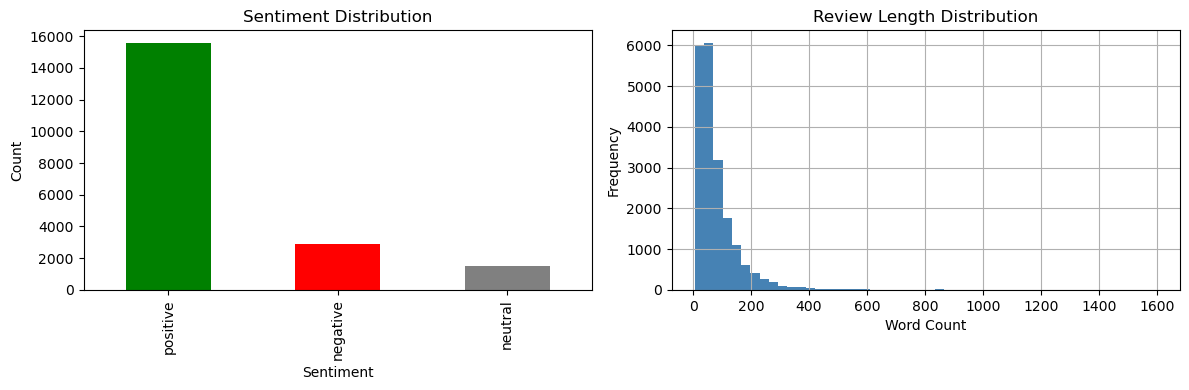

Average review length: 80.47 words


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red', 'gray'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

df['review_length'] = df['Text'].apply(lambda x: len(str(x).split()))
df['review_length'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_plots.png')
plt.show()

print("Average review length:", round(df['review_length'].mean(), 2), "words")

In [10]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

y_pred = lr_model.predict(X_test_tfidf)

print("TF-IDF + Logistic Regression Results:")
print(classification_report(y_test, y_pred))

TF-IDF + Logistic Regression Results:
              precision    recall  f1-score   support

    negative       0.53      0.67      0.59       577
     neutral       0.24      0.45      0.31       304
    positive       0.93      0.81      0.87      3119

    accuracy                           0.76      4000
   macro avg       0.57      0.64      0.59      4000
weighted avg       0.82      0.76      0.78      4000



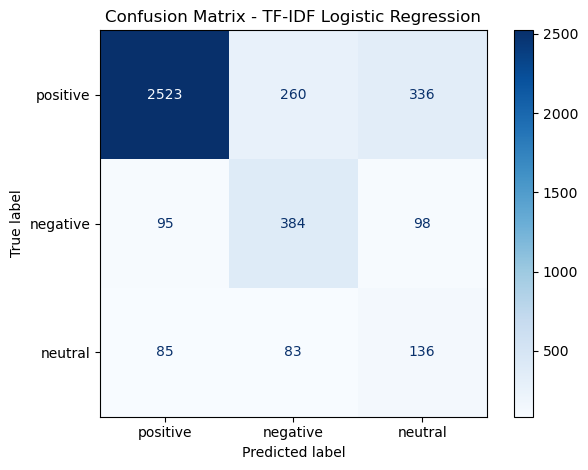

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=['positive', 'negative', 'neutral'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positive', 'negative', 'neutral'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - TF-IDF Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

In [12]:
negative_reviews = df[df['sentiment'] == 'negative']['clean_text']

tfidf_lda = TfidfVectorizer(max_features=1000, ngram_range=(1,1))
X_lda = tfidf_lda.fit_transform(negative_reviews)

lda_model = LatentDirichletAllocation(n_components=6, random_state=42, max_iter=10)
lda_model.fit(X_lda)

feature_names = tfidf_lda.get_feature_names_out()

print("LDA Topics from Negative Reviews:")
for idx, topic in enumerate(lda_model.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-8:]]
    print(f"Topic {idx+1}: {', '.join(top_words)}")

LDA Topics from Negative Reviews:
Topic 1: food, would, good, one, product, flavor, like, taste
Topic 2: jerky, truffle, hair, jelly, olive, kona, oil, cherry
Topic 3: good, roast, flavor, like, taste, cup, tea, coffee
Topic 4: fake, cocoa, dont, waste, money, like, chocolate, taste
Topic 5: price, item, dog, box, bag, would, amazon, product
Topic 6: pasta, made, noodle, day, chip, china, food, dog


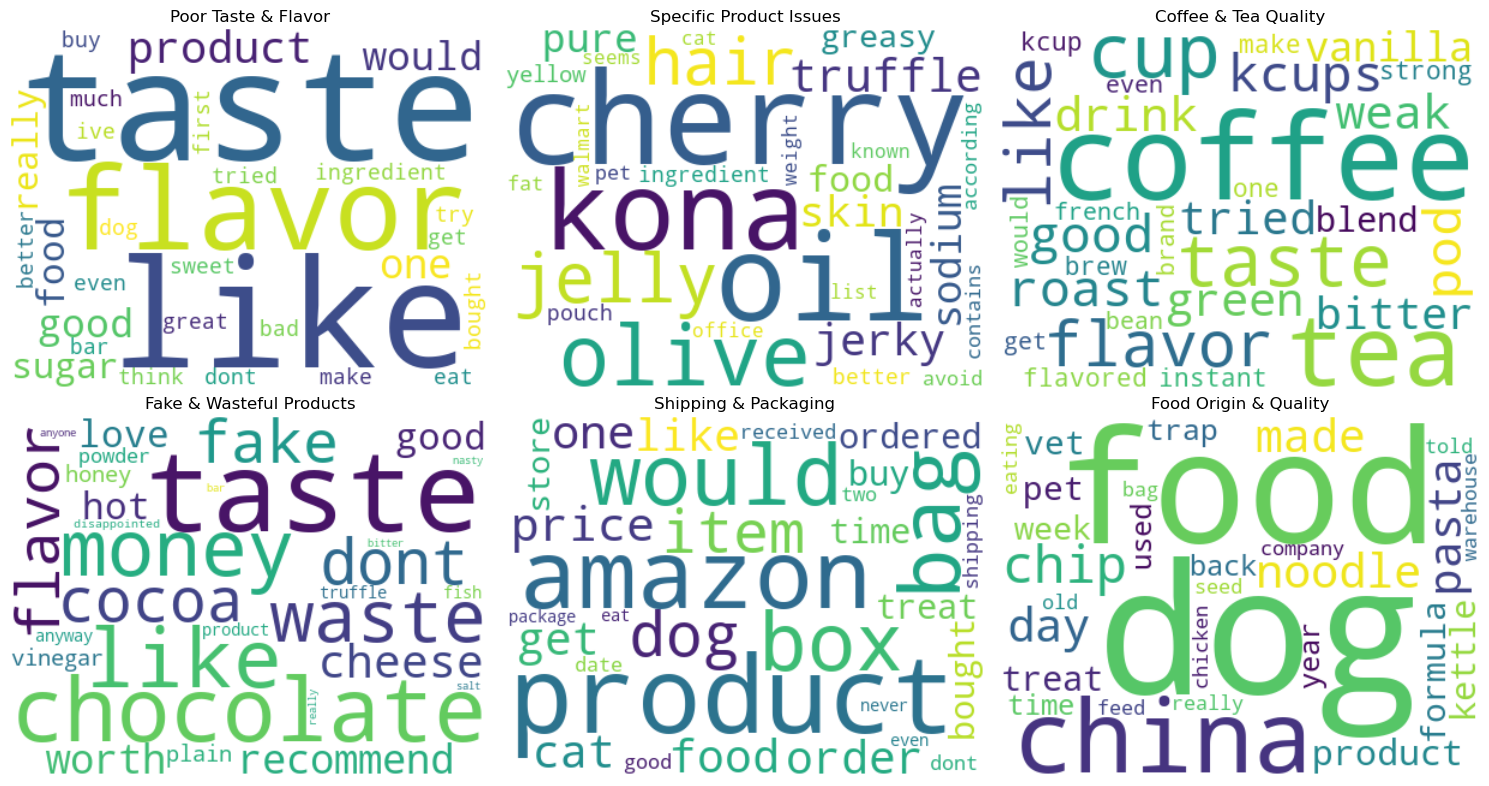

In [13]:
topic_labels = {
    0: 'Poor Taste & Flavor',
    1: 'Specific Product Issues',
    2: 'Coffee & Tea Quality',
    3: 'Fake & Wasteful Products',
    4: 'Shipping & Packaging',
    5: 'Food Origin & Quality'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, topic in enumerate(lda_model.components_):
    top_words = {feature_names[i]: topic[i] for i in topic.argsort()[-30:]}
    wc = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(top_words)
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(topic_labels[idx])
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('topic_wordclouds.png')
plt.show()

In [14]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

sample_texts = X_test[:200].tolist()
sample_labels = y_test[:200].tolist()

transformer_preds = []
for text in sample_texts:
    result = sentiment_pipeline(text[:512])[0]
    label = result['label']
    if label == 'POSITIVE':
        transformer_preds.append('positive')
    else:
        transformer_preds.append('negative')

filtered_labels = [l for l in sample_labels if l != 'neutral']
filtered_preds = [transformer_preds[i] for i, l in enumerate(sample_labels) if l != 'neutral']

print("DistilBERT Results (positive/negative only):")
print(classification_report(filtered_labels, filtered_preds))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

DistilBERT Results (positive/negative only):
              precision    recall  f1-score   support

    negative       0.29      0.90      0.44        29
    positive       0.97      0.57      0.72       146

    accuracy                           0.62       175
   macro avg       0.63      0.73      0.58       175
weighted avg       0.85      0.62      0.67       175



In [15]:
from transformers import pipeline

sentiment_pipeline = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

sample_texts = X_test[:200].tolist()
sample_labels = y_test[:200].tolist()

transformer_preds = []
for text in sample_texts:
    result = sentiment_pipeline(text[:512])[0]
    label = result['label']
    if label == 'POSITIVE':
        transformer_preds.append('positive')
    else:
        transformer_preds.append('negative')

filtered_labels = [l for l in sample_labels if l != 'neutral']
filtered_preds = [transformer_preds[i] for i, l in enumerate(sample_labels) if l != 'neutral']

print("DistilBERT Results (positive/negative only):")
print(classification_report(filtered_labels, filtered_preds))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT Results (positive/negative only):
              precision    recall  f1-score   support

    negative       0.29      0.90      0.44        29
    positive       0.97      0.57      0.72       146

    accuracy                           0.62       175
   macro avg       0.63      0.73      0.58       175
weighted avg       0.85      0.62      0.67       175



In [16]:
print("Model Comparison:")
print("Model                  | Accuracy | Positive F1 | Negative F1")
print("TF-IDF + LogReg        | 0.76     | 0.87        | 0.59")
print("DistilBERT (zero-shot) | 0.62     | 0.72        | 0.44")
print("\nConclusion:")
print("TF-IDF + Logistic Regression performs better on this dataset.")
print("DistilBERT is a general model - fine-tuning would improve it significantly.")

Model Comparison:
Model                  | Accuracy | Positive F1 | Negative F1
TF-IDF + LogReg        | 0.76     | 0.87        | 0.59
DistilBERT (zero-shot) | 0.62     | 0.72        | 0.44

Conclusion:
TF-IDF + Logistic Regression performs better on this dataset.
DistilBERT is a general model - fine-tuning would improve it significantly.


In [18]:
lines = [
    "Customer Review Sentiment Analysis - Product Insights Report\n",
    "\nDataset\n",
    "- Source: Amazon Fine Food Reviews\n",
    "- Size: 20,000 reviews\n",
    "- Ratings: 1-5 stars\n",
    "\nSentiment Distribution\n",
    "- Positive (4-5 stars): 15,595 reviews (78%)\n",
    "- Negative (1-2 stars): 2,886 reviews (14%)\n",
    "- Neutral (3 stars): 1,519 reviews (8%)\n",
    "\nModel Performance\n",
    "- TF-IDF + Logistic Regression: Accuracy 76%, F1 0.87 (positive), F1 0.59 (negative)\n",
    "- DistilBERT zero-shot: Accuracy 62%, F1 0.72 (positive), F1 0.44 (negative)\n",
    "- TF-IDF model outperforms DistilBERT zero-shot on this domain-specific dataset\n",
    "\nTop Complaints from Negative Reviews\n",
    "1. Poor Taste & Flavor - customers unhappy with taste, texture, and flavor\n",
    "2. Fake & Wasteful Products - chocolate, cocoa products labeled as fake or misleading\n",
    "3. Coffee & Tea Quality - bitter taste, poor roast quality\n",
    "4. Shipping & Packaging - damaged boxes, wrong items, Amazon delivery issues\n",
    "5. Food Origin Concerns - products made in China, dog food quality issues\n",
    "6. Specific Product Issues - jerky, olive oil, cherry products frequently complained about\n",
    "\nTop Praise Themes from Positive Reviews\n",
    "- Great taste and flavor\n",
    "- Good value for money\n",
    "- Fresh and high quality ingredients\n",
    "- Fast delivery and good packaging\n",
    "\n3 Actionable Recommendations\n",
    "1. Improve product labeling - customers feel misled about ingredients and origin\n",
    "2. Review chocolate and cocoa product quality - high complaint volume in this category\n",
    "3. Strengthen packaging for shipping - many complaints about damaged or wrong items\n",
    "\nHow to Run\n",
    "1. Clone the repository\n",
    "2. Install: pip install -r requirements.txt\n",
    "3. Place Reviews.csv in project folder\n",
    "4. Open sentiment_analysis.ipynb and run all cells\n",
]

with open('README.md', 'w') as f:
    f.writelines(lines)

req = "pandas==2.3.3\nnumpy==2.3.5\nmatplotlib==3.10.3\nseaborn==0.13.2\nscikit-learn==1.7.2\nnltk==3.9.2\nwordcloud==1.9.6\npyLDAvis==3.4.1\ntransformers==5.10.2\ntorch==2.12.0\n"

with open('requirements.txt', 'w') as f:
    f.write(req)

print("README.md and requirements.txt created!")

README.md and requirements.txt created!


In [2]:
import os
for f in os.listdir():
    if f.endswith('.ipynb') or f.endswith('.md') or f.endswith('.txt'):
        print(f)

hashes.txt
README.md
requirements.txt
sentiment_analysis .ipynb
Untitled.ipynb
